# Exploratory Data Analysis (EDA) for MIMIC‑III ICU Mortality Prediction


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/mimic_project'
patients_df = pd.read_csv(f'{save_dir}/patients_labels_demo.csv')
vitals_df = pd.read_csv(f'{save_dir}/vitals_raw.csv')

Mounted at /content/drive


### 2. Cohort Composition and Class Balance


In [2]:
print("cohort shape:", patients_df.shape)
print("\nmissing values per column:")
print(patients_df.isnull().sum())

print("\nmortality label counts:")
print(patients_df['mortality_label'].value_counts())
print("mortality rate:", patients_df['mortality_label'].mean())

cohort shape: (36515, 14)

missing values per column:
subject_id            0
hadm_id               0
icustay_id            0
intime                0
outtime               0
los_hours             0
gender                0
dob                   0
age                   0
admission_type        0
insurance             0
ethnicity             0
marital_status     2087
mortality_label       0
dtype: int64

mortality label counts:
mortality_label
0    32565
1     3950
Name: count, dtype: int64
mortality rate: 0.10817472271669178


### 3. Length of Stay Distribution



los_hours summary:
count    36515.000000
mean        98.479885
std        146.006925
min          1.000000
25%         29.000000
50%         50.000000
75%         99.000000
max       3695.000000
Name: los_hours, dtype: float64


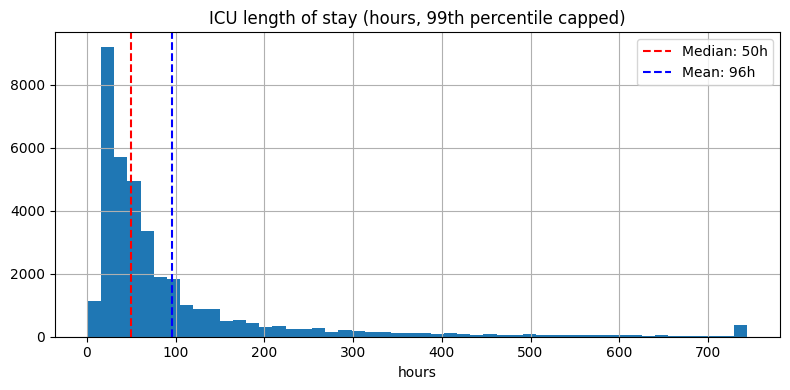

In [3]:
print("\nlos_hours summary:")
print(patients_df['los_hours'].describe())

plt.figure(figsize=(8,4))
data = patients_df['los_hours'].clip(upper=patients_df['los_hours'].quantile(0.99))
data.hist(bins=50)
plt.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.0f}h')
plt.axvline(data.mean(), color='blue', linestyle='--', label=f'Mean: {data.mean():.0f}h')
plt.title('ICU length of stay (hours, 99th percentile capped)')
plt.xlabel('hours')
plt.legend()
plt.tight_layout()
plt.show()

### 4. Demographics Overview

In [4]:
print(patients_df['gender'].value_counts())

print("\nage summary:")
print(patients_df['age'].describe())

print(patients_df['admission_type'].value_counts())

print(patients_df['ethnicity'].value_counts().head(10))

gender
M    21101
F    15414
Name: count, dtype: int64

age summary:
count    36515.000000
mean        62.346981
std         16.852608
min         18.000000
25%         52.000000
50%         64.000000
75%         76.000000
max         89.000000
Name: age, dtype: float64
admission_type
EMERGENCY    29418
ELECTIVE      6001
URGENT        1096
Name: count, dtype: int64
ethnicity
WHITE                             25593
UNKNOWN/NOT SPECIFIED              3604
BLACK/AFRICAN AMERICAN             2625
HISPANIC OR LATINO                  961
OTHER                               862
UNABLE TO OBTAIN                    730
ASIAN                               556
PATIENT DECLINED TO ANSWER          378
ASIAN - CHINESE                     180
HISPANIC/LATINO - PUERTO RICAN      138
Name: count, dtype: int64


### 5. Mortality Patterns by Subgroup


In [5]:
patients_df['age_band'] = pd.cut(patients_df['age'], bins=[18,40,60,75,89])
print("\nmortality by age band:")
print(patients_df.groupby('age_band', observed=False)['mortality_label'].mean())

print("\nmortality by admission type:")
print(patients_df.groupby('admission_type')['mortality_label'].mean())


mortality by age band:
age_band
(18, 40]    0.053976
(40, 60]    0.079674
(60, 75]    0.104678
(75, 89]    0.169335
Name: mortality_label, dtype: float64

mortality by admission type:
admission_type
ELECTIVE     0.025662
EMERGENCY    0.124856
URGENT       0.112226
Name: mortality_label, dtype: float64


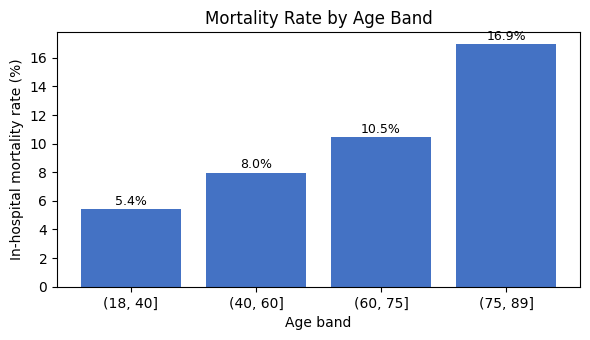

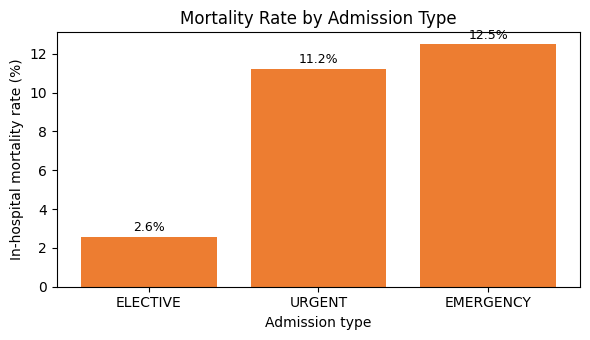

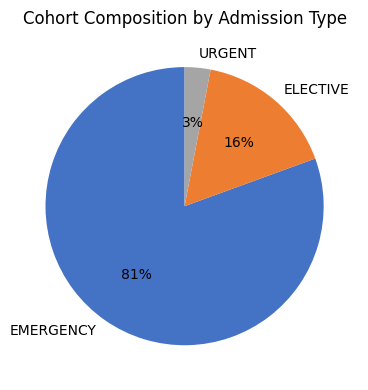

In [6]:
mortality_by_age = patients_df.groupby('age_band', observed=False)['mortality_label'].mean()

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(mortality_by_age.index.astype(str), mortality_by_age.values * 100, color='#4472C4')
ax.set_ylabel('In-hospital mortality rate (%)')
ax.set_xlabel('Age band')
ax.set_title('Mortality Rate by Age Band')
for bar, v in zip(bars, mortality_by_age.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

mortality_by_adm = patients_df.groupby('admission_type')['mortality_label'].mean().sort_values()

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(mortality_by_adm.index, mortality_by_adm.values * 100, color='#ED7D31')
ax.set_ylabel('In-hospital mortality rate (%)')
ax.set_xlabel('Admission type')
ax.set_title('Mortality Rate by Admission Type')
for bar, v in zip(bars, mortality_by_adm.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

adm_counts = patients_df['admission_type'].value_counts()

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.pie(adm_counts.values, labels=adm_counts.index, autopct='%1.0f%%', startangle=90,
       colors=['#4472C4', '#ED7D31', '#A5A5A5'], textprops={'fontsize': 10})
ax.set_title('Cohort Composition by Admission Type')
plt.tight_layout()
plt.show()

### 6. Vital Signs Data Quality

In [7]:
print("\nvalue ranges per vital (checking for implausible outliers):")
print(vitals_df.groupby('item_label')['valuenum'].describe()[['min', 'max']])



value ranges per vital (checking for implausible outliers):
                                        min           max
item_label                                               
Arterial BP [Diastolic]                 0.0  2.980000e+02
Arterial BP [Systolic]                  0.0  3.000000e+02
Arterial Blood Pressure diastolic     -16.0  9.315598e+04
Arterial Blood Pressure systolic      -11.0  9.511904e+04
Heart Rate                              0.0  8.610100e+04
Manual BP [Diastolic]                   0.0  1.640000e+02
Manual BP [Systolic]                    0.0  2.500000e+02
NBP [Diastolic]                         0.0  2.850000e+02
NBP [Systolic]                          0.0  3.000000e+02
Non Invasive Blood Pressure diastolic   0.0  1.051110e+05
Non Invasive Blood Pressure systolic  -69.0  1.271060e+05
O2 saturation pulseoxymetry             0.0  6.363333e+06
Resp Rate (Total)                       0.0  1.230000e+02
Respiratory Rate                        0.0  2.355555e+06
Respiratory

### 7. Vital Signs Coverage per Patient



vitals readings per patient stay:
count     35993.000000
mean        613.654349
std        1597.315671
min           1.000000
25%         171.000000
50%         293.000000
75%         594.000000
max      170631.000000
dtype: float64


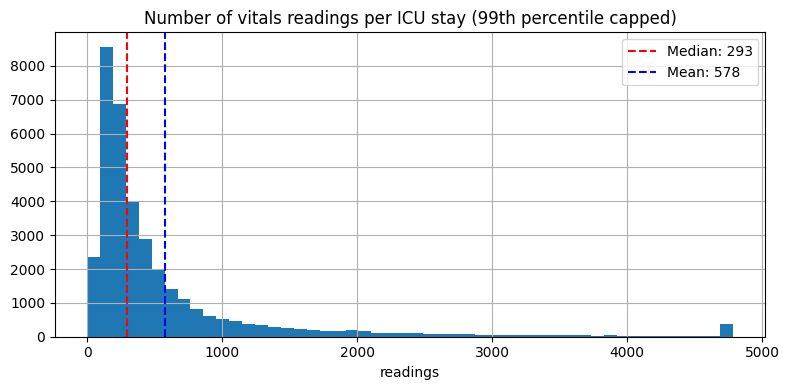

In [8]:
readings_per_patient = vitals_df.groupby('icustay_id').size()

print("\nvitals readings per patient stay:")
print(readings_per_patient.describe())

plt.figure(figsize=(8,4))
data = readings_per_patient.clip(upper=readings_per_patient.quantile(0.99))
data.hist(bins=50)
plt.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.0f}')
plt.axvline(data.mean(), color='blue', linestyle='--', label=f'Mean: {data.mean():.0f}')
plt.title('Number of vitals readings per ICU stay (99th percentile capped)')
plt.xlabel('readings')
plt.legend()
plt.tight_layout()
plt.show()